### Flight Delay Prediction Model

#### 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Dashboard color palette
BLUE   = '#4a90d9'
ORANGE = '#e8834a'

plt.rcParams['figure.facecolor'] = '#f8f9fa'
plt.rcParams['axes.facecolor']   = '#ffffff'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.3

print("Libraries loaded")


Libraries loaded


#### 2. Load Data

In [33]:
df = pd.read_csv(r"C:\Users\kncba\OneDrive\Desktop\flights.csv")
print(f"Loaded from CSV")
print(f"Shape: {df.shape}")
df.head()

Loaded from CSV
Shape: (336776, 21)


,id,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,...,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour,name
0,0,2013,1,1,517.0,515,2.0,830.0,819,11.0,...,1545,N14228,EWR,IAH,227.0,1400,5,15,2013-01-01 05:00:00,United Air Lines Inc.
1,1,2013,1,1,533.0,529,4.0,850.0,830,20.0,...,1714,N24211,LGA,IAH,227.0,1416,5,29,2013-01-01 05:00:00,United Air Lines Inc.
2,2,2013,1,1,542.0,540,2.0,923.0,850,33.0,...,1141,N619AA,JFK,MIA,160.0,1089,5,40,2013-01-01 05:00:00,American Airlines Inc.
3,3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,...,725,N804JB,JFK,BQN,183.0,1576,5,45,2013-01-01 05:00:00,JetBlue Airways
4,4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,...,461,N668DN,LGA,ATL,116.0,762,6,0,2013-01-01 06:00:00,Delta Air Lines Inc.


#### 3. Create Target Variable
Matching the dashboard's 15-minute threshold:
- 1 = Delayed - arr_delay > 15
- 0 = On-time - arr_delay ≤ 15


In [34]:
df = df.dropna(subset=['arr_delay', 'dep_delay'])
df['is_delayed'] = (df['arr_delay'] > 15).astype(int)

counts = df['is_delayed'].value_counts()
print(f"On-time : {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)")
print(f"Delayed : {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)")


On-time : 249,716 (76.3%)
Delayed : 77,630 (23.7%)


#### 4. Feature Engineering

In [ ]:
features = ['month', 'day', 'hour', 'dep_delay', 'distance',
            'carrier', 'origin', 'dest']

export_cols = features + ['flight', 'name', 'arr_delay', 'is_delayed']
df_model = df[[c for c in export_cols if c in df.columns]].dropna().copy()

# Encode categoricals
le_carrier = LabelEncoder()
le_origin  = LabelEncoder()
le_dest    = LabelEncoder()

df_model['carrier_enc'] = le_carrier.fit_transform(df_model['carrier'])
df_model['origin_enc']  = le_origin.fit_transform(df_model['origin'])
df_model['dest_enc']    = le_dest.fit_transform(df_model['dest'])

feature_cols = ['month', 'day', 'hour', 'dep_delay', 'distance',
                'carrier_enc', 'origin_enc', 'dest_enc']

X = df_model[feature_cols]
y = df_model['is_delayed']

print(f"Features : {feature_cols}")
print(f"Samples  : {len(X):,}")


Features : ['month', 'day', 'hour', 'dep_delay', 'distance', 'carrier_enc', 'origin_enc', 'dest_enc']
Samples  : 327,346


#### 5. Train / Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")


Train : 261,876  |  Test : 65,470


#### 6. Train Models
- Logistic Regression - interpretable baseline

In [37]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

print("Models trained ✓")


Models trained ✓


#### 7. Evaluation

In [38]:
for name, model in [('Logistic Regression', lr)]:
    y_pred = model.predict(X_test)
    auc    = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"{'='*52}")
    print(f"  {name}  |  ROC-AUC: {auc:.4f}")
    print(f"{'='*52}")
    print(classification_report(y_test, y_pred, target_names=['On-time', 'Delayed']))

  Logistic Regression  |  ROC-AUC: 0.9015
              precision    recall  f1-score   support

     On-time       0.90      0.97      0.94     49944
     Delayed       0.88      0.67      0.76     15526

    accuracy                           0.90     65470
   macro avg       0.89      0.82      0.85     65470
weighted avg       0.90      0.90      0.89     65470



#### 8. Visualizations

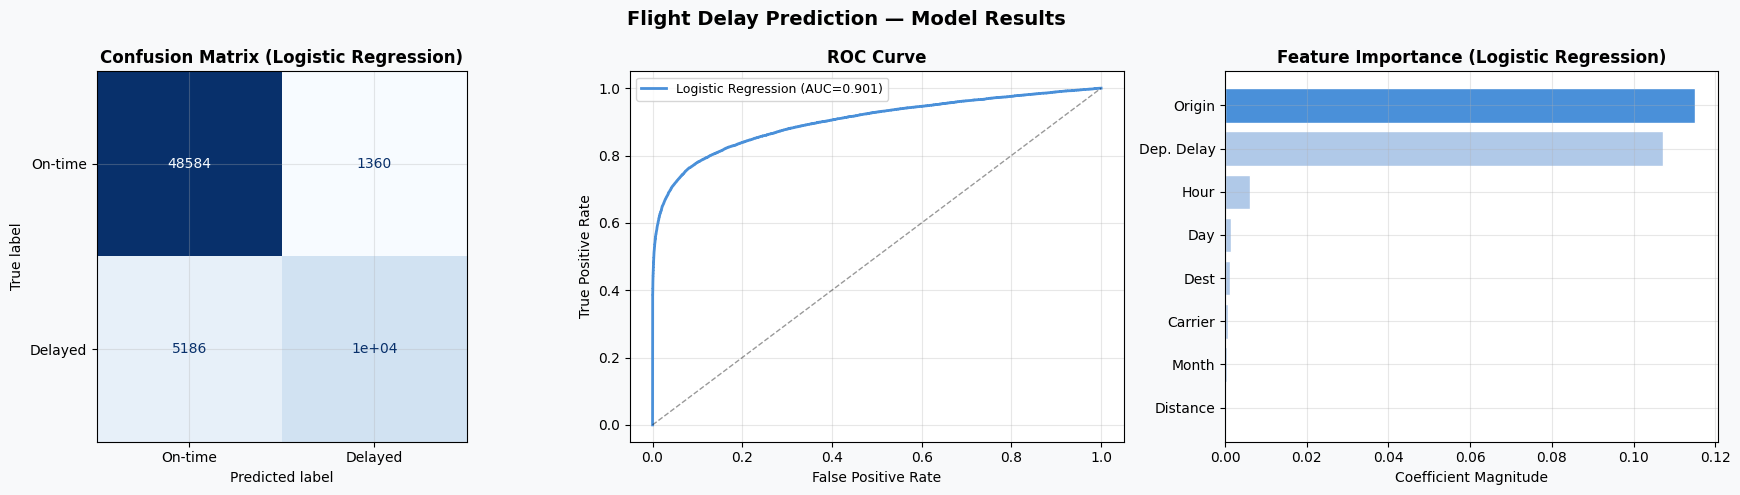

Saved: model_results.png


In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Flight Delay Prediction — Model Results', fontsize=14, fontweight='bold')

# Confusion Matrix (Logistic Regression)
y_pred_lr = lr.predict(X_test)
cm = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm, display_labels=['On-time', 'Delayed']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')

axes[0].set_title('Confusion Matrix (Logistic Regression)', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, lr.predict_proba(X_test)[:, 1])
auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])

axes[1].plot(fpr, tpr, label=f'Logistic Regression (AUC={auc:.3f})', color=BLUE, lw=2)
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(fontsize=9)

# Feature Importance (Logistic Regression → coefficients instead of RF importances)
feat_labels = ['Month','Day','Hour','Dep. Delay','Distance','Carrier','Origin','Dest']
imp = np.abs(lr.coef_[0])  # use absolute coefficients as importance proxy

idx = np.argsort(imp)
colors = [BLUE if i == idx[-1] else '#b0c9e8' for i in idx]

axes[2].barh([feat_labels[i] for i in idx], imp[idx], color=colors, edgecolor='white')
axes[2].set_title('Feature Importance (Logistic Regression)', fontweight='bold')
axes[2].set_xlabel('Coefficient Magnitude')

plt.tight_layout()
plt.savefig('model_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: model_results.png")

#### 9. Try a Prediction


In [40]:
def predict_flight(month, day, hour, dep_delay, distance, carrier, origin, dest):
    """Predict arrival delay for a single flight."""
    
    def safe_encode(le, val):
        try:
            return le.transform([val])[0]
        except ValueError:
            return -1

    sample = pd.DataFrame([[
        month, day, hour, dep_delay, distance,
        safe_encode(le_carrier, carrier),
        safe_encode(le_origin, origin),
        safe_encode(le_dest, dest)
    ]], columns=feature_cols)

    prob = lr.predict_proba(sample)[0][1]
    label = 'DELAYED' if prob > 0.5 else 'ON-TIME'

    print(f"Result      : {label}")
    print(f"Delay Prob. : {prob*100:.1f}%")

    return label, prob


# Example
predict_flight(
    month=7, day=15, hour=17, dep_delay=20,
    distance=1400, carrier='UA', origin='EWR', dest='IAH'
)

Result      : ON-TIME
Delay Prob. : 42.6%


('ON-TIME', np.float64(0.42621383449824135))

#### 10. Export Model

In [ ]:
import pickle

model_data = {
    "coef": lr.coef_[0].tolist(),
    "intercept": lr.intercept_[0],
    
    # safer than storing full LabelEncoders
    "carrier_classes": le_carrier.classes_.tolist(),
    "origin_classes": le_origin.classes_.tolist(),
    "dest_classes": le_dest.classes_.tolist(),
    
    "feature_cols": feature_cols,
    
    "distance_lookup": df[['origin', 'dest', 'distance']].drop_duplicates().to_dict('records')
}

with open('flight_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Logistic Regression model exported successfully!")

Logistic Regression model exported successfully!
